# Q-Regime
## Small-Data Quantum Kernel Learning for Financial Volatility Regime Classification

This notebook contains the final reproducible pipeline for comparing
classical and quantum kernel methods for short-horizon S&P 500
volatility-regime classification.

In [1622]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score,
)

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
import time



# Parameters :3

Note: You're supposed to have `spx_bloomberg_gk_volatility.csv` in the `data/processed` folder... We can't publish it on github because of licensing concerns :3

In [1623]:
# Preprocessing and feature engineering parameters
# Modeling parameters will be defined later in the notebook

START_DATE = "2010-01-01"
END_DATE = "2025-01-01"

TRAIN_PERIOD = ["2010-01-01", "2020-12-31"] #2010-2020
VAL_PERIOD = ["2021-01-01", "2022-12-31"] # 2021-2022
TEST_PERIOD = ["2023-01-01", "2024-12-31"] # 2023-2024

H= 5 # Prediction horizon
QUANTILE_THRESHOLD = 0.67 # Threshold for high volatility regime

# Results
GLOBAL_SUMMARY = []
MACRO_GLOBAL_SUMMARY = []

RESULTS = []
MACRO_RESULTS = []

# Source and output directories
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

BLOOMBERG_VOL_FILENAME = PROCESSED_DIR / "spx_bloomberg_gk_volatility.csv" # Please reach out if you need this file !

In [1624]:
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Noura\Desktop\Archives\Projects\Competitions\qubit-crew_QFF2026_uottawa


#### Utility functions

In [1625]:
def reset_results():
    global GLOBAL_SUMMARY, MACRO_GLOBAL_SUMMARY, RESULTS, MACRO_RESULTS
    GLOBAL_SUMMARY = []
    MACRO_GLOBAL_SUMMARY = []
    RESULTS = []
    MACRO_RESULTS = []

In [1626]:
# SUMMARY METRICS
BALANCED_ACCURACY = "Balanced Accuracy"
ROC_AUC = "ROC-AUC"
F1 = "F1"
RECALL_HIGH_VOL = "Recall High Volatility"

DATA_REGIME = "Data Regime"
MODEL_NAME = "Model"
SPLIT = "Split"
WINDOW = "Window"
START = "Start Date"
END = "End Date"

TRAINING_TIME = "Training Time"
PREDICTION_TIME = "Prediction Time"


In [1627]:
def summarize_metrics(model_name, N, start_date, end_date, y_val, y_val_pred, y_val_score, train_time, prediction_time, split="Validation", regime="Small", window="N/A"):
    metrics = {
            DATA_REGIME: regime,
            SPLIT: split,
            MODEL_NAME: model_name,
            "N": N,
            WINDOW: window,
            START: start_date,
            END: end_date,
            TRAINING_TIME: train_time,
            PREDICTION_TIME: prediction_time,
            BALANCED_ACCURACY: balanced_accuracy_score(y_val, y_val_pred),
            ROC_AUC: roc_auc_score(y_val, y_val_score),
            F1: f1_score(y_val, y_val_pred),
            RECALL_HIGH_VOL: recall_score(y_val, y_val_pred)
    }
    metrics_df = pd.DataFrame([metrics])
    display(metrics_df)
    GLOBAL_SUMMARY.append(metrics_df)
    return metrics_df

In [1628]:
def report_results(experiment, model, metrics, X_train, Y_train, X_val, Y_val, y_val_pred, y_val_score, scaled=False):
    results = {
        "experiment": experiment,
        "model": model,
        "X_train": X_train,
        "Y_train": Y_train,
        "X_val": X_val,
        "Y_val": Y_val,
        "y_val_pred": y_val_pred,
        "y_val_score": y_val_score,
        "summary_metrics": metrics
    }
    RESULTS.append(results)
    return results

In [1629]:
def report_macro_results(experiment,results):
    MACRO_RESULTS.append({"experiment": experiment,"results": results})
    return results

In [1630]:
def aggregate_window_metrics(window_results):
    result_dfs = []
    for result in window_results:
        summary_metrics = result["summary_metrics"]
        result_dfs.append(summary_metrics)

    combined_results_df = (
        pd.concat(result_dfs, ignore_index=True)
        .groupby("N")
        .agg(
            split=("Split", "first"),
            data_regime=("Data Regime", "first"),
            model_name=("Model", "first"),
            avg_training_time=(TRAINING_TIME, "mean"),
            avg_prediction_time=(PREDICTION_TIME, "mean"),
            balanced_accuracy_mean=(BALANCED_ACCURACY, "mean"),
            balanced_accuracy_std=(BALANCED_ACCURACY, "std"),
            roc_auc_mean=(ROC_AUC, "mean"),
            roc_auc_std=(ROC_AUC, "std"),
            f1_mean=(F1, "mean"),
            f1_std=(F1, "std"),
            recall_mean=(RECALL_HIGH_VOL, "mean"),
            recall_std=(RECALL_HIGH_VOL, "std"),
        )
        .reset_index()
    )

    combined_results_df = combined_results_df[
        [
            "split",
            "data_regime",
            "model_name",
            "N",
            "avg_training_time",
            "avg_prediction_time",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "roc_auc_mean",
            "roc_auc_std",
            "f1_mean",
            "f1_std",
            "recall_mean",
            "recall_std",
        ]
    ]
    MACRO_GLOBAL_SUMMARY.append(combined_results_df)
    display(combined_results_df)


    return combined_results_df


In [1631]:
def format_time(seconds):
    minutes = int(seconds // 60)
    remaining_seconds = seconds % 60
    return f"{minutes} min {remaining_seconds:.2f} sec"

def global_summary_table():
    summary_table = pd.concat(GLOBAL_SUMMARY, ignore_index=True)
    summary_table[TRAINING_TIME] = summary_table[TRAINING_TIME].apply(lambda x: format_time(x))
    summary_table[PREDICTION_TIME] = summary_table[PREDICTION_TIME].apply(lambda x: format_time(x))
    return summary_table

def macro_summary_table():
    summary_table = pd.concat(MACRO_GLOBAL_SUMMARY, ignore_index=True)
    summary_table["avg_training_time"] = summary_table["avg_training_time"].apply(lambda x: format_time(x))
    summary_table["avg_prediction_time"] = summary_table["avg_prediction_time"].apply(lambda x: format_time(x))
    return summary_table

In [1632]:
def prep_data(train, val, feature_cols, target_col="high_vol"):
    X_train = train[feature_cols]
    y_train = train[target_col].astype(int)

    X_val = val[feature_cols]
    y_val = val[target_col].astype(int)

   
    summary_table = pd.DataFrame({
        "Split": ["Train", "Validation"],
        "N": [len(X_train), len(X_val)],
        "Features": [X_train.shape[1], X_val.shape[1]],
        "Positive labels": [
            y_train.sum(),
            y_val.sum()
        ],
        "Positive rate": [
            y_train.mean(),
            y_val.mean()
        ]
    })

    display(summary_table)

    return X_train, y_train, X_val, y_val


In [1633]:
def scale_X(X_train, X_val):
    start_date = X_train.index.min()
    end_date = X_train.index.max()
    # Scale all features to [0, pi]
    scaler = MinMaxScaler(
        feature_range=(0, np.pi),
        clip=True
    )

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled, start_date, end_date

## 1. Load source data

In [1634]:
# Load S&P 500 daily market data
sp500 = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex columns if needed
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500.index = pd.to_datetime(sp500.index)
sp500.index.name = "Date"

# Load Bloomberg Garman-Klass historical volatility
bloomberg_vol = pd.read_csv(
    BLOOMBERG_VOL_FILENAME,
    parse_dates=["Date"]
)

bloomberg_vol = bloomberg_vol.set_index("Date")

print("Yahoo shape:", sp500.shape)
print("Yahoo range:", sp500.index.min(), "to", sp500.index.max())

print("\nBloomberg shape:", bloomberg_vol.shape)
print("Bloomberg range:", bloomberg_vol.index.min(), "to", bloomberg_vol.index.max())

Yahoo shape: (3774, 6)
Yahoo range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00

Bloomberg shape: (3774, 2)
Bloomberg range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00


## 2. Merge market and volatility data

In [1635]:
# Merge Yahoo market data with Bloomberg Garman-Klass volatility
data = sp500.join(
    bloomberg_vol,
    how="inner"
)

# Rename Bloomberg columns for cleaner code
data = data.rename(columns={
    "SPX Index Hist Vol (5)": "gk_vol_5d",
    "SPX Index Hist Vol (20)": "gk_vol_20d"
})

print("Merged shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())

print("\nMissing values:")
print(data.isna().sum())

data.head()

Merged shape: (3774, 8)
Date range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00

Missing values:
Adj Close     0
Close         0
High          0
Low           0
Open          0
Volume        0
gk_vol_5d     0
gk_vol_20d    0
dtype: int64


,Adj Close,Close,High,Low,Open,Volume,gk_vol_5d,gk_vol_20d
Date,,,,,,,,
2010-01-04,1132.989990,1132.989990,1133.869995,1116.560059,1116.560059,3991400000,6.895809,8.975828
2010-01-05,1136.520020,1136.520020,1136.630005,1129.660034,1132.660034,2491020000,6.737916,7.516543
2010-01-06,1137.140015,1137.140015,1139.189941,1133.949951,1135.709961,4972660000,6.907034,7.266088
2010-01-07,1141.689941,1141.689941,1142.459961,1131.319946,1136.270020,5270680000,8.006896,7.198322
2010-01-08,1144.979980,1144.979980,1145.390015,1136.219971,1140.520020,4389590000,8.077482,7.032808


## 3. Create prediction target

In [1636]:
# Future 5-day Garman-Klass volatility target
# At date t, use the Bloomberg 5-day historical volatility observed 5 trading days later.
data["future_gk_vol_5d"] = data["gk_vol_5d"].shift(-5)

print(
    data[
        ["gk_vol_5d", "future_gk_vol_5d"]
    ].tail(10)
)

            gk_vol_5d  future_gk_vol_5d
Date                                   
2024-12-17   5.124125         17.694100
2024-12-18  12.098636         14.167424
2024-12-19  12.943466         14.460431
2024-12-20  16.658055         11.182908
2024-12-23  17.583497         10.412080
2024-12-24  17.694100               NaN
2024-12-26  14.167424               NaN
2024-12-27  14.460431               NaN
2024-12-30  11.182908               NaN
2024-12-31  10.412080               NaN


In [1637]:
train_raw = data.loc[TRAIN_PERIOD[0]:TRAIN_PERIOD[1]].copy()
val_raw   = data.loc[VAL_PERIOD[0]:VAL_PERIOD[1]].copy()
test_raw  = data.loc[TEST_PERIOD[0]:TEST_PERIOD[1]].copy()

# Prevent future target windows from crossing split boundaries
train_raw = train_raw.iloc[:-H].copy()
val_raw = val_raw.iloc[:-H].copy()

print(
    "Train:",
    train_raw.index.min(),
    "to",
    train_raw.index.max(),
    train_raw.shape
)

print(
    "Validation:",
    val_raw.index.min(),
    "to",
    val_raw.index.max(),
    val_raw.shape
)

print(
    "Test:",
    test_raw.index.min(),
    "to",
    test_raw.index.max(),
    test_raw.shape
)

Train: 2010-01-04 00:00:00 to 2020-12-23 00:00:00 (2764, 9)
Validation: 2021-01-04 00:00:00 to 2022-12-22 00:00:00 (498, 9)
Test: 2023-01-03 00:00:00 to 2024-12-31 00:00:00 (502, 9)


## 4. Define high-volatility regime

In [1638]:
high_vol_threshold = (
    train_raw["future_gk_vol_5d"]
    .dropna()
    .quantile(QUANTILE_THRESHOLD)
)

print("High-volatility threshold:", high_vol_threshold)

High-volatility threshold: 11.2243938342


In [1639]:
data["high_vol"] = (
    (data["future_gk_vol_5d"] > high_vol_threshold)
    .astype(float)
    .where(data["future_gk_vol_5d"].notna())
)

print(
    data[
        ["future_gk_vol_5d", "high_vol"]
    ].tail(10)
)

            future_gk_vol_5d  high_vol
Date                                  
2024-12-17         17.694100       1.0
2024-12-18         14.167424       1.0
2024-12-19         14.460431       1.0
2024-12-20         11.182908       0.0
2024-12-23         10.412080       0.0
2024-12-24               NaN       NaN
2024-12-26               NaN       NaN
2024-12-27               NaN       NaN
2024-12-30               NaN       NaN
2024-12-31               NaN       NaN


## 5. Create model features

In [1640]:
# Daily log return
data["log_return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

# 1-day return
data["return_1d"] = data["log_return"]

# 5-day momentum
data["momentum_5d"] = (
    data["log_return"]
    .rolling(window=5)
    .sum()
)

feature_cols = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d"
]

model_data = data[
    feature_cols
    + ["future_gk_vol_5d", "high_vol"]
].dropna().copy()

print("Model data shape:", model_data.shape)
print("Date range:", model_data.index.min(), "to", model_data.index.max())

model_data.head()

Model data shape: (3764, 6)
Date range: 2010-01-11 00:00:00 to 2024-12-23 00:00:00


,return_1d,momentum_5d,gk_vol_5d,gk_vol_20d,future_gk_vol_5d,high_vol
Date,,,,,,
2010-01-11,0.001745,0.012272,7.661832,7.061430,10.355161,0.0
2010-01-12,-0.009425,-0.000264,8.449730,7.241153,11.928864,1.0
2010-01-13,0.008291,0.007482,10.081274,7.771405,13.199877,1.0
2010-01-14,0.002423,0.005912,9.414070,7.731066,14.483879,1.0
2010-01-15,-0.010882,-0.007847,10.363180,8.018520,14.080746,1.0


## 6. Create chronological train / validation / test splits

In [1641]:
train = model_data.loc[TRAIN_PERIOD[0]:TRAIN_PERIOD[1]].iloc[:-H].copy()
val   = model_data.loc[VAL_PERIOD[0]:VAL_PERIOD[1]].iloc[:-H].copy()
test  = model_data.loc[TEST_PERIOD[0]:TEST_PERIOD[1]].copy()

print(
    "Train:",
    train.shape,
    train.index.min(),
    "to",
    train.index.max()
)

print(
    "Validation:",
    val.shape,
    val.index.min(),
    "to",
    val.index.max()
)

print(
    "Test:",
    test.shape,
    test.index.min(),
    "to",
    test.index.max()
)

print("\nHigh-volatility rates:")
print("Train:", train["high_vol"].mean())
print("Validation:", val["high_vol"].mean())
print("Test:", test["high_vol"].mean())

Train: (2759, 6) 2010-01-11 00:00:00 to 2020-12-23 00:00:00
Validation: (498, 6) 2021-01-04 00:00:00 to 2022-12-22 00:00:00
Test: (497, 6) 2023-01-03 00:00:00 to 2024-12-23 00:00:00

High-volatility rates:
Train: 0.33055454874954693
Validation: 0.5783132530120482
Test: 0.2575452716297787


In [1642]:
# saving Preprocessed datasets 
train.to_csv(PROCESSED_DIR / "train.csv")
val.to_csv(PROCESSED_DIR / "val.csv")
test.to_csv(PROCESSED_DIR / "test.csv")

## 7. Define model inputs and persistence baseline

In [1643]:
X_train, y_train, X_val, y_val = prep_data(train, val,  feature_cols)

,Split,N,Features,Positive labels,Positive rate
0,Train,2759,4,912,0.330555
1,Validation,498,4,288,0.578313


##### Persistence with no threshold

In [1644]:
def persistence_baseline(X,Y):
    persistence_auc_5d = roc_auc_score(
        Y,
        X["gk_vol_5d"]
    )

    persistence_auc_20d = roc_auc_score(
        Y,
        X["gk_vol_20d"]
    )

    print("5-day GK persistence AUC:", persistence_auc_5d)
    print("20-day GK persistence AUC:", persistence_auc_20d)
    return persistence_auc_5d, persistence_auc_20d

In [1645]:
persistence_auc_5d, persistence_auc_20d = persistence_baseline(X_val,y_val)

5-day GK persistence AUC: 0.8591269841269841
20-day GK persistence AUC: 0.8520337301587302


#### Persistence with threshold


(To make it comparable to our models)

In [1646]:
THRESHOLD = 0.67

def persistence_baseline_with_threshold(X, y, threshold=THRESHOLD):
    score_5d = X["gk_vol_5d"]
    pred_5d = (score_5d >= threshold).astype(int)
    train_time_5d = 0.0
    results = []

    metrics_5d = summarize_metrics(
        model_name=f"Persistence 5d >= {threshold}",
        N=len(X),
        start_date=X.index.min(),
        end_date=X.index.max(),
        y_val=y,
        y_val_pred=pred_5d,
        y_val_score=score_5d,
        train_time=train_time_5d,
        prediction_time=0.0,
        split="Validation",
        regime="Classical"
    )

    results.append(
                report_results(
                experiment="Baseline Persistence - 5d",
                model=None,
                metrics=metrics_5d,
                X_train=None,
                Y_train=None,
                X_val=X,
                Y_val=y,
                y_val_pred=pred_5d,
                y_val_score=score_5d
        )
    )


    score_20d = X["gk_vol_20d"]
    pred_20d = (score_20d >= threshold).astype(int)
    train_time_20d = 0.0
    metrics_20d = summarize_metrics(
        model_name=f"Persistence 20d >= {threshold}",
        N=len(X),
        start_date=X.index.min(),
        end_date=X.index.max(),
        y_val=y,
        y_val_pred=pred_20d,
        y_val_score=score_20d,
        train_time=train_time_20d,
        prediction_time=0.0,
        split="Validation",
        regime="Classical"
    )
 
    results.append(
        report_results(
            experiment="Baseline Persistence - 20d",
            model=None,
            metrics=metrics_20d,
            X_train=None,
            Y_train=None,
            X_val=X,
            Y_val=y,
            y_val_pred=pred_20d,
            y_val_score=score_20d
        )
    )

    report_macro_results(experiment="Persistence Baseline", results=results)

    

persistence_baseline_with_threshold(X_val,y_val)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 0.67,498,N/A,2021-01-04,2022-12-22,0.0,0.0,0.5,0.859127,0.732824,1.0


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 20d >= 0.67,498,N/A,2021-01-04,2022-12-22,0.0,0.0,0.5,0.852034,0.732824,1.0


## 8. Classical RBF-SVM baseline 

In [1647]:
def rbf_svc_baseline(X_train_scaled, X_val_scaled, X_val, y_val, y_train, start_date, end_date, gamma="scale", model_name="RBF-SVM", regime="Classical", window="N/A"):

    # RBF-SVM model with balanced class weights to handle class imbalance
    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma,
        class_weight="balanced",
        random_state=42
    )

    start_training_time = time.perf_counter()

    model.fit(
        X_train_scaled,
        y_train
    )

    training_time = time.perf_counter() - start_training_time

    start_prediction_time = time.perf_counter()
    
    y_val_pred = model.predict(X_val_scaled)
    y_val_score = model.decision_function(X_val_scaled)

    prediction_time = time.perf_counter() - start_prediction_time

    N = len(X_train_scaled)

    summary_metrics = summarize_metrics(model_name = model_name,
                                        N=N, 
                                        start_date=start_date, 
                                        end_date=end_date,
                                        y_val=y_val, 
                                        y_val_pred=y_val_pred, 
                                        y_val_score=y_val_score, 
                                        train_time=training_time,
                                        prediction_time=prediction_time,
                                        regime=regime, 
                                        window=window)

    results = report_results(experiment=f"{regime} {model_name} - N={N}", model=model, metrics=summary_metrics, X_train=X_train_scaled, Y_train=y_train, X_val=X_val_scaled, Y_val=y_val, y_val_pred=y_val_pred, y_val_score=y_val_score, scaled=True)


    return results

In [1648]:
def train_classical_rbf_svc(X_train, y_train, X_val, y_val):
    X_train_scaled, X_val_scaled, start_date, end_date = scale_X(X_train, X_val)
    classical_rbf_results = rbf_svc_baseline(X_train_scaled, X_val_scaled, X_val, y_val, y_train, start_date, end_date)
    report_macro_results(experiment="Classical RBF-SVM", results=[classical_rbf_results])
    return classical_rbf_results

In [1649]:
classical_rbf_results = train_classical_rbf_svc(X_train, y_train, X_val, y_val)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,RBF-SVM,2759,N/A,2010-01-11,2020-12-23,0.116062,0.069378,0.795734,0.890823,0.842454,0.881944


In [1650]:
global_summary_table()

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.859127,0.732824,1.000000
1,Classical,Validation,Persistence 20d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.852034,0.732824,1.000000
2,Classical,Validation,RBF-SVM,2759,N/A,2010-01-11,2020-12-23,0 min 0.12 sec,0 min 0.07 sec,0.795734,0.890823,0.842454,0.881944


## 9. Small-data chronological windows

### Parameters

In [1651]:
N_VALUES = [20, 50, 100, 200]
N_WINDOWS = 3

In [1652]:
def thin_data(train, val, H):
    # Reduce overlap between neighboring 5-day targets
    train_thin = train.iloc[::H].copy()
    val_thin = val.iloc[::H].copy()

    summary_table = pd.DataFrame({
        "Dataset": ["Train", "Validation"],
        "Original size": [len(train), len(val)],
        "Thinned size": [len(train_thin), len(val_thin)],
        "Thinned high-volatility rate": [
            train_thin["high_vol"].mean(),
            val_thin["high_vol"].mean()
        ]
    })

    print(summary_table.to_string(index=False))
    return train_thin, val_thin
    

In [1653]:
train_thin, val_thin = thin_data(train, val, H)

   Dataset  Original size  Thinned size  Thinned high-volatility rate
     Train           2759           552                      0.327899
Validation            498           100                      0.590000


In [1654]:
def generate_windows(train_thin, N_values=N_VALUES, n_windows=N_WINDOWS):
    
    window_indices = {}
    

    for N in N_values:

        max_start = len(train_thin) - N

        starts = np.linspace(
            0,
            max_start,
            n_windows,
            dtype=int
        )

        window_indices[N] = []
        summary_rows = []

        

        for window_id, start in enumerate(starts, start=1):
            window = train_thin.iloc[start:start + N]

            window_indices[N].append(window.index)

            summary_rows.append({
            "N": N,
            "Window": window_id,
            "Start": window.index.min().date(),
            "End": window.index.max().date(),
            "High-vol rate": round(window["high_vol"].mean(), 3)
            })

    
        summary_df = pd.DataFrame(summary_rows)
        display(summary_df)

   
    return window_indices

In [1655]:
window_indices = generate_windows(train_thin, N_values=N_VALUES, n_windows=N_WINDOWS)

,N,Window,Start,End,High-vol rate
0,20,1,2010-01-11,2010-05-27,0.55
1,20,2,2015-04-24,2015-09-09,0.25
2,20,3,2020-08-05,2020-12-18,0.50


,N,Window,Start,End,High-vol rate
0,50,1,2010-01-11,2010-12-30,0.60
1,50,2,2015-01-06,2015-12-24,0.32
2,50,3,2019-12-31,2020-12-18,0.62


,N,Window,Start,End,High-vol rate
0,100,1,2010-01-11,2011-12-27,0.60
1,100,2,2014-07-09,2016-06-24,0.32
2,100,3,2019-01-03,2020-12-18,0.41


,N,Window,Start,End,High-vol rate
0,200,1,2010-01-11,2013-12-23,0.410
1,200,2,2013-07-11,2017-06-22,0.170
2,200,3,2017-01-06,2020-12-18,0.325


#### Scaled data

In [1656]:
def prep_small_data(train_thin, window_indices, feature_set, N_values=N_VALUES):
    datasets = []
    for N in N_values:

        for window_id, idx in enumerate(window_indices[N], start=1):

            window = train_thin.loc[idx]

            X_train_window = window[feature_set]
            y_train_window = window["high_vol"].astype(int)

            X_val_window = val_thin[feature_set]
            y_val_window = val_thin["high_vol"].astype(int)

            X_train_scaled, X_val_scaled, start_date, end_date = scale_X(X_train_window, X_val_window)
            datasets.append((X_train_window, X_train_scaled, y_train_window, X_val_window,  X_val_scaled, y_val_window, N, window_id, start_date, end_date))

    summary_table = pd.DataFrame([
        {
            "N": N,
            "Window": window_id,
            "Start": start_date,
            "End": end_date,
            "Train high-volatility rate": y_train_window.mean()
        }
        for X_train_window, X_train_scaled, y_train_window, X_val_window,  X_val_scaled, y_val_window, N, window_id, start_date, end_date in datasets
    ])

    display(summary_table)
    return datasets

In [1657]:
datasets = prep_small_data(train_thin, window_indices,feature_cols, N_values=N_VALUES)

,N,Window,Start,End,Train high-volatility rate
0,20,1,2010-01-11,2010-05-27,0.550
1,20,2,2015-04-24,2015-09-09,0.250
2,20,3,2020-08-05,2020-12-18,0.500
3,50,1,2010-01-11,2010-12-30,0.600
4,50,2,2015-01-06,2015-12-24,0.320
5,50,3,2019-12-31,2020-12-18,0.620
6,100,1,2010-01-11,2011-12-27,0.600
7,100,2,2014-07-09,2016-06-24,0.320
8,100,3,2019-01-03,2020-12-18,0.410
9,200,1,2010-01-11,2013-12-23,0.410


## 10. Small-data classical RBF-SVM

In [1658]:
def small_rbf_svm(datasets, model_name="RBF-SVM"):
    results = []

    for X_train_window, X_train_scaled, y_train_window, X_val_window,  X_val_scaled, y_val_window, N, window_id, start_date, end_date in datasets:
        result = rbf_svc_baseline(
            X_train_scaled = X_train_scaled, 
            X_val_scaled = X_val_scaled, 
            X_val = X_val_window, 
            y_val = y_val_window, 
            y_train = y_train_window,
            start_date = start_date, 
            end_date = end_date, 
            regime="Small", 
            model_name=model_name,
            window=window_id
        )
        results.append(result)
    report_macro_results(experiment="Small RBF-SVM", results=results)
    return results

In [1659]:
small_rbf_results = small_rbf_svm(datasets)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,20,1,2010-01-11,2010-05-27,0.003196,0.000598,0.730881,0.86358,0.6875,0.559322


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,20,2,2015-04-24,2015-09-09,0.001659,0.000528,0.770566,0.875568,0.777778,0.711864


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,20,3,2020-08-05,2020-12-18,0.001595,0.000511,0.826168,0.870194,0.854701,0.847458


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,50,1,2010-01-11,2010-12-30,0.00448,0.002572,0.763125,0.899959,0.785714,0.745763


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,50,2,2015-01-06,2015-12-24,0.001875,0.000747,0.786895,0.887557,0.850394,0.915254


...

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,100,2,2014-07-09,2016-06-24,0.002106,0.000985,0.813973,0.904093,0.847458,0.847458


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,100,3,2019-01-03,2020-12-18,0.001975,0.00131,0.788549,0.895825,0.817391,0.79661


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,200,1,2010-01-11,2013-12-23,0.002804,0.001626,0.806532,0.898718,0.852459,0.881356


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,200,2,2013-07-11,2017-06-22,0.002511,0.001468,0.778421,0.879289,0.84127,0.898305


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,200,3,2017-01-06,2020-12-18,0.002601,0.001301,0.799091,0.906573,0.857143,0.915254


In [1660]:
global_summary_table()

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.859127,0.732824,1.000000
1,Classical,Validation,Persistence 20d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.852034,0.732824,1.000000
2,Classical,Validation,RBF-SVM,2759,N/A,2010-01-11,2020-12-23,0 min 0.12 sec,0 min 0.07 sec,0.795734,0.890823,0.842454,0.881944
3,Small,Validation,RBF-SVM,20,1,2010-01-11,2010-05-27,0 min 0.00 sec,0 min 0.00 sec,0.730881,0.863580,0.687500,0.559322
4,Small,Validation,RBF-SVM,20,2,2015-04-24,2015-09-09,0 min 0.00 sec,0 min 0.00 sec,0.770566,0.875568,0.777778,0.711864
5,Small,Validation,RBF-SVM,20,3,2020-08-05,2020-12-18,0 min 0.00 sec,0 min 0.00 sec,0.826168,0.870194,0.854701,0.847458
6,Small,Validation,RBF-SVM,50,1,2010-01-11,2010-12-30,0 min 0.00 sec,0 min 0.00 sec,0.763125,0.899959,0.785714,0.745763
7,Small,Validation,RBF-SVM,50,2,2015-01-06,2015-12-24,0 min 0.00 sec,0 min 0.00 sec,0.786895,0.887557,0.850394,0.915254
8,Small,Validation,RBF-SVM,50,3,2019-12-31,2020-12-18,0 min 0.00 sec,0 min 0.00 sec,0.752584,0.881356,0.732673,0.627119
9,Small,Validation,RBF-SVM,100,1,2010-01-11,2011-12-27,0 min 0.00 sec,0 min 0.00 sec,0.773253,0.894585,0.752475,0.644068


## 11. Aggregate classical small-data results

In [1661]:
small_rbf_aggregated_results = aggregate_window_metrics(small_rbf_results)

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,RBF-SVM,20,0.002150,0.000546,0.775872,0.047865,0.869781,0.006005,0.773326,0.083689,0.706215,0.144151
1,Validation,Small,RBF-SVM,50,0.002930,0.001402,0.767535,0.017576,0.889624,0.009472,0.789594,0.058956,0.762712,0.144814
2,Validation,Small,RBF-SVM,100,0.002051,0.001134,0.791925,0.020569,0.898167,0.005169,0.805775,0.048545,0.762712,0.105847
3,Validation,Small,RBF-SVM,200,0.002639,0.001465,0.794681,0.014565,0.894860,0.014045,0.850291,0.008156,0.898305,0.016949


In [1662]:
macro_summary_table()

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,RBF-SVM,20,0 min 0.00 sec,0 min 0.00 sec,0.775872,0.047865,0.869781,0.006005,0.773326,0.083689,0.706215,0.144151
1,Validation,Small,RBF-SVM,50,0 min 0.00 sec,0 min 0.00 sec,0.767535,0.017576,0.889624,0.009472,0.789594,0.058956,0.762712,0.144814
2,Validation,Small,RBF-SVM,100,0 min 0.00 sec,0 min 0.00 sec,0.791925,0.020569,0.898167,0.005169,0.805775,0.048545,0.762712,0.105847
3,Validation,Small,RBF-SVM,200,0 min 0.00 sec,0 min 0.00 sec,0.794681,0.014565,0.894860,0.014045,0.850291,0.008156,0.898305,0.016949


# 11.Small Quantum SVC 

In [1663]:
import qiskit
import qiskit_machine_learning
from qiskit.circuit.library import zz_feature_map
from IPython.display import display
from qiskit_machine_learning.kernels import FidelityQuantumKernel



print("Qiskit version:", qiskit.__version__)
print("Qiskit Machine Learning version:", qiskit_machine_learning.__version__)



Qiskit version: 2.5.2
Qiskit Machine Learning version: 0.9.1


In [1664]:
def feature_map_circuit(X_train, reps=1, entanglement="linear"):
    print(f"Generating Feature Map Circuit | N = {len(X_train)} | Start : {X_train.index.min()} | End: {X_train.index.max()}")
    num_features = X_train.shape[1]
    feature_map = zz_feature_map(
        feature_dimension=num_features,
        reps=reps,
        entanglement=entanglement
    )

    
    print("Number of qubits:", feature_map.num_qubits)
    print("Circuit depth:", feature_map.depth())
    fig = feature_map.draw("mpl")
    display(fig)
    return feature_map


In [1665]:
def q_svc(X_train, X_train_scaled, y_train, X_val_scaled, y_val, start_date, end_date, model_name="Quantum SVC", regime="Small", window="N/A"):

    
    feature_map = feature_map_circuit(X_train, reps=1, entanglement="linear")

    
    quantum_kernel = FidelityQuantumKernel(
        feature_map=feature_map
    )
    
    model = QSVC(
                quantum_kernel=quantum_kernel,
                C=1,
                class_weight="balanced"
            )

    start_training_time = time.perf_counter()
    model.fit(
        X_train_scaled,
        y_train
    )
    training_time = time.perf_counter() - start_training_time


    start_prediction_time = time.perf_counter()

    y_val_pred = model.predict(X_val_scaled)
    y_val_score = model.decision_function(X_val_scaled)

    prediction_time = time.perf_counter() - start_prediction_time

    summary_metrics = summarize_metrics(
        model_name=model_name,
        N=len(X_train_scaled),
        start_date=start_date,
        end_date=end_date,
        y_val=y_val,
        y_val_pred=y_val_pred,
        y_val_score=y_val_score,
        train_time=training_time,
        prediction_time=prediction_time,
        regime=regime,
        window=window
    )

    results = report_results(
        experiment=f"{regime} {model_name} - N={len(X_train_scaled)}",
        model=model,
        metrics=summary_metrics,
        X_train=X_train_scaled,
        Y_train=y_train,
        X_val=X_val_scaled,
        Y_val=y_val,
        y_val_pred=y_val_pred,
        y_val_score=y_val_score,
        scaled=True
    )
    

    return results

In [1666]:
def train_classical_quantum_svc(X_train, y_train, X_val, y_val):
    X_train_scaled, X_val_scaled, start_date, end_date = scale_X(X_train, X_val)
    classical_q_results = q_svc(X_train, X_train_scaled, y_train, X_val_scaled, y_val, start_date, end_date)
    macro_results = report_macro_results(experiment="Classical Quantum SVC", results=[classical_q_results])
    return classical_q_results

# THE DATASET IS SO BIG IT CAUSES A MEMORY ERROR!!!
#classical_q_results = train_classical_quantum_svc(X_train, y_train, X_val, y_val)

In [1667]:
def small_q_svc(datasets, model_name="Quantum SVC"):
    results = []

    for X_train_window, X_train_scaled, y_train_window, X_val_window,  X_val_scaled, y_val_window, N, window_id, start_date, end_date in datasets:
        result = q_svc(X_train = X_train_window, 
                       X_train_scaled = X_train_scaled, 
                       y_train = y_train_window,
                       X_val_scaled = X_val_scaled, 
                       y_val = y_val_window, 
                       start_date = start_date, 
                       end_date=end_date, 
                       regime="Small", 
                       model_name=model_name,
                       window=window_id)

           
        results.append(result)
       
    return results



Generating Feature Map Circuit | N = 20 | Start : 2010-01-11 00:00:00 | End: 2010-05-27 00:00:00
Number of qubits: 4
Circuit depth: 11


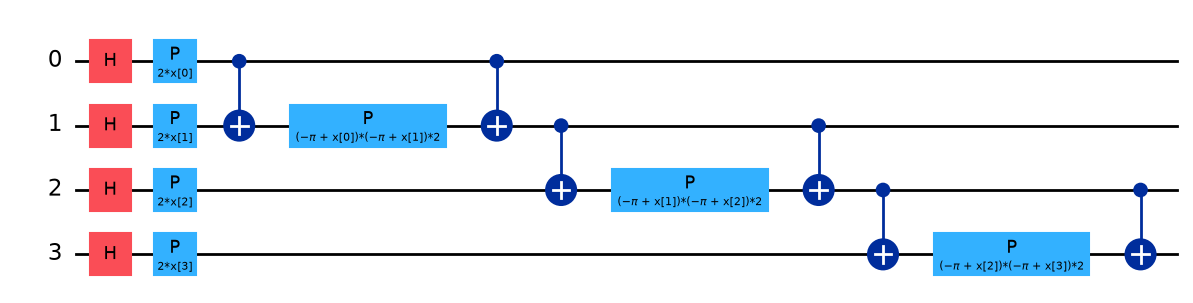

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC,20,1,2010-01-11,2010-05-27,0.54735,11.505774,0.644895,0.629599,0.716667,0.728814


Generating Feature Map Circuit | N = 20 | Start : 2015-04-24 00:00:00 | End: 2015-09-09 00:00:00
Number of qubits: 4
Circuit depth: 11


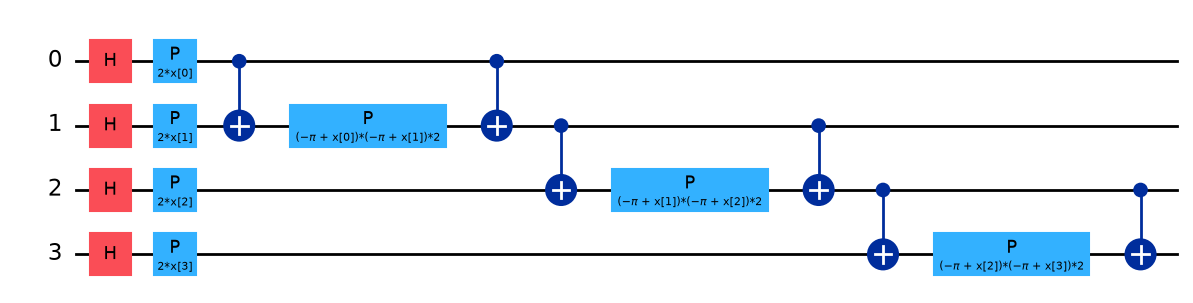

KeyboardInterrupt: 

In [1668]:
small_q_svc_results = small_q_svc(datasets)

# 12 - Aggregating Small QSVC results

In [ ]:
aggregated_small_q_svc_results = aggregate_window_metrics(small_q_svc_results)

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,Quantum SVC,20,0.593688,11.552208,0.571448,0.065053,0.591153,0.061646,0.584692,0.207366,0.581921,0.299542
1,Validation,Small,Quantum SVC,50,3.706805,30.554422,0.615544,0.092160,0.693537,0.106964,0.709658,0.084530,0.751412,0.110278
2,Validation,Small,Quantum SVC,100,14.321179,57.313656,0.718754,0.038716,0.748932,0.019040,0.763382,0.063941,0.762712,0.132377
3,Validation,Small,Quantum SVC,200,59.108358,116.243622,0.711313,0.044997,0.779661,0.024137,0.772111,0.059296,0.796610,0.117427


# 13- Global Summary

In [ ]:
global_summary_table()

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.859127,0.732824,1.000000
1,Classical,Validation,Persistence 20d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.852034,0.732824,1.000000
2,Classical,Validation,RBF-SVM,2759,N/A,2010-01-11,2020-12-23,0 min 0.12 sec,0 min 0.09 sec,0.795734,0.890823,0.842454,0.881944
3,Small,Validation,RBF-SVM,20,1,2010-01-11,2010-05-27,0 min 0.00 sec,0 min 0.00 sec,0.730881,0.863580,0.687500,0.559322
4,Small,Validation,RBF-SVM,20,2,2015-04-24,2015-09-09,0 min 0.00 sec,0 min 0.00 sec,0.770566,0.875568,0.777778,0.711864
5,Small,Validation,RBF-SVM,20,3,2020-08-05,2020-12-18,0 min 0.00 sec,0 min 0.00 sec,0.826168,0.870194,0.854701,0.847458
6,Small,Validation,RBF-SVM,50,1,2010-01-11,2010-12-30,0 min 0.00 sec,0 min 0.00 sec,0.763125,0.899959,0.785714,0.745763
7,Small,Validation,RBF-SVM,50,2,2015-01-06,2015-12-24,0 min 0.00 sec,0 min 0.00 sec,0.786895,0.887557,0.850394,0.915254
8,Small,Validation,RBF-SVM,50,3,2019-12-31,2020-12-18,0 min 0.00 sec,0 min 0.00 sec,0.752584,0.881356,0.732673,0.627119
9,Small,Validation,RBF-SVM,100,1,2010-01-11,2011-12-27,0 min 0.00 sec,0 min 0.00 sec,0.773253,0.894585,0.752475,0.644068


In [ ]:
macro_summary_table()

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,RBF-SVM,20,0 min 0.00 sec,0 min 0.00 sec,0.775872,0.047865,0.869781,0.006005,0.773326,0.083689,0.706215,0.144151
1,Validation,Small,RBF-SVM,50,0 min 0.00 sec,0 min 0.00 sec,0.767535,0.017576,0.889624,0.009472,0.789594,0.058956,0.762712,0.144814
2,Validation,Small,RBF-SVM,100,0 min 0.00 sec,0 min 0.00 sec,0.791925,0.020569,0.898167,0.005169,0.805775,0.048545,0.762712,0.105847
3,Validation,Small,RBF-SVM,200,0 min 0.00 sec,0 min 0.00 sec,0.794681,0.014565,0.894860,0.014045,0.850291,0.008156,0.898305,0.016949
4,Validation,Small,Quantum SVC,20,0 min 0.59 sec,0 min 11.55 sec,0.571448,0.065053,0.591153,0.061646,0.584692,0.207366,0.581921,0.299542
5,Validation,Small,Quantum SVC,50,0 min 3.71 sec,0 min 30.55 sec,0.615544,0.092160,0.693537,0.106964,0.709658,0.084530,0.751412,0.110278
6,Validation,Small,Quantum SVC,100,0 min 14.32 sec,0 min 57.31 sec,0.718754,0.038716,0.748932,0.019040,0.763382,0.063941,0.762712,0.132377
7,Validation,Small,Quantum SVC,200,0 min 59.11 sec,1 min 56.24 sec,0.711313,0.044997,0.779661,0.024137,0.772111,0.059296,0.796610,0.117427


In [ ]:
def save_results_to_csv(suffix=""):
    global_summary = global_summary_table()
    macro_summary = macro_summary_table()

    global_summary.to_csv(RESULTS_DIR / f"global_summary_{suffix}.csv", index=False)
    macro_summary.to_csv(RESULTS_DIR / f"macro_summary_{suffix}.csv", index=False)

    print("Results saved to CSV files.")

In [ ]:
save_results_to_csv()

Results saved to CSV files.


In [ ]:
def visualize_global_summary():
    metrics = ["Balanced Accuracy", "ROC-AUC", "F1", "Recall High Volatility"]
    
    d = global_summary_table()
    # x-axis label: Small regime by N, Classical as its own group
    d["Setting"] = np.where(d["Data Regime"] == "Small",
                            "Small N=" + d["N"].astype(str), "Classical (full)")
    
    # Macro-average over windows (mean + std across windows; std=0/NaN if single run)
    g = d.groupby(["Setting", "Model"])[metrics]
    mean, std = g.mean(), g.std().fillna(0)
    
    order = ["Small N=20", "Small N=50", "Small N=100", "Small N=200", "Classical (full)"]
    models = ["Quantum SVC", "RBF-SVM", "Persistence 5d >= 0.67", "Persistence 20d >= 0.67"]
    colors = {"Quantum SVC": "#7b3fe4", "RBF-SVM": "#1f77b4",
            "Persistence 5d >= 0.67": "#aaaaaa", "Persistence 20d >= 0.67": "#666666"}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    w = 0.2
    for ax, m in zip(axes.ravel(), metrics):
        for i, mod in enumerate(models):
            xs, ys, es = [], [], []
            for j, s in enumerate(order):
                if (s, mod) in mean.index:
                    xs.append(j + (i - 1.5) * w)
                    ys.append(mean.loc[(s, mod), m])
                    es.append(std.loc[(s, mod), m])
            ax.bar(xs, ys, w, yerr=es, capsize=2, label=mod, color=colors[mod])
        if m in ("Balanced Accuracy", "ROC-AUC"):
            ax.axhline(0.5, ls="--", c="red", lw=0.8)  # chance level
        ax.set_title(m)
        ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=20)
        ax.grid(axis="y", alpha=0.3)
    
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Model Performance Metrics by Setting\n"
                "(mean over windows, error bars = std across windows)")
    plt.tight_layout()
    plt.show()
    
   
    

In [ ]:
import re
   
def visualize_small_regime():
    df = pd.concat(GLOBAL_SUMMARY, ignore_index=True)
        

    metrics = ["Balanced Accuracy", "ROC-AUC", "F1", "Recall High Volatility"]
    colors = {"Quantum SVC": "#7b3fe4", "RBF-SVM": "#1f77b4"}

    s = df[df["Data Regime"] == "Small"].copy()
    s["Train s"] = s["Training Time"]
    s["Pred s"] = s["Prediction Time"]

    cols = metrics + ["Train s", "Pred s"]
    g = s.groupby(["Model", "N"])[cols]
    mean, std = g.mean(), g.std().fillna(0)
    models = list(colors)
    Ns = sorted(s["N"].unique())

    fig, axes = plt.subplots(3, 4, figsize=(18, 11))


    def line(ax, col, log=False):
        for mod in models:
            mu = mean.loc[mod, col].reindex(Ns)
            sd = std.loc[mod, col].reindex(Ns)
            if log:  # RBF times are ~0, so floor them for the log axis
                mu, lo, hi = mu.clip(lower=0.01), (mu - sd).clip(lower=0.01), mu + sd
            else:
                lo, hi = mu - sd, mu + sd
            ax.plot(Ns, mu, "o-", c=colors[mod], label=mod)
            ax.fill_between(Ns, lo, hi, color=colors[mod], alpha=0.15)
            # individual windows
            pts = s[s["Model"] == mod]
            ax.scatter(pts["N"], pts[col].clip(lower=0.01) if log else pts[col],
                    c=colors[mod], s=12, alpha=0.4)
        ax.set_xscale("log")
        ax.set_xticks(Ns)
        ax.set_xticklabels(Ns)
        ax.set_xlabel("Training size N")
        ax.grid(alpha=0.3)
        if log:
            ax.set_yscale("log")


    # Row 1: metrics vs N
    for ax, m in zip(axes[0], metrics):
        line(ax, m)
        ax.set_title(m)
        ax.set_ylim(0, 1.05)
        if m in ("Balanced Accuracy", "ROC-AUC"):
            ax.axhline(0.5, ls="--", c="red", lw=0.8)
    axes[0, 0].legend()

    # Row 2: times, quantum-minus-classical gap, performance vs cost
    line(axes[1, 0], "Train s", log=True)
    axes[1, 0].set_title("Training time (s, log; RBF floored at 0.01)")
    line(axes[1, 1], "Pred s", log=True)
    axes[1, 1].set_title("Prediction time (s, log; RBF floored at 0.01)")

    gap = mean.xs("Quantum SVC", level="Model")[metrics] - mean.xs("RBF-SVM", level="Model")[metrics]
    for m in metrics:
        axes[1, 2].plot(gap.index, gap[m], "o-", label=m)
    axes[1, 2].axhline(0, c="k", lw=0.8)
    axes[1, 2].set_xscale("log")
    axes[1, 2].set_xticks(Ns)
    axes[1, 2].set_xticklabels(Ns)
    axes[1, 2].set_xlabel("Training size N")
    axes[1, 2].set_title("Gap: Quantum - RBF-SVM (mean over windows)")
    axes[1, 2].legend(fontsize=8)
    axes[1, 2].grid(alpha=0.3)

    for mod in models:
        mu = mean.loc[mod].reindex(Ns)
        axes[1, 3].plot(mu["Pred s"].clip(lower=0.01), mu["ROC-AUC"], "o-", c=colors[mod], label=mod)
        for n, x, y in zip(Ns, mu["Pred s"].clip(lower=0.01), mu["ROC-AUC"]):
            axes[1, 3].annotate(f"N={n}", (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
    axes[1, 3].set_xscale("log")
    axes[1, 3].set_xlabel("Prediction time (s)")
    axes[1, 3].set_ylabel("ROC-AUC")
    axes[1, 3].set_title("Performance vs. inference cost")
    axes[1, 3].grid(alpha=0.3)

    # Row 3: per-window view (is the quantum model stable across time periods?)
    for ax, m in zip(axes[2], metrics):
        for mod in models:
            for w, marker in zip(sorted(s["Window"].unique()), ["o", "s", "^"]):
                p = s[(s["Model"] == mod) & (s["Window"] == w)].sort_values("N")
                ax.plot(p["N"], p[m], marker=marker, ls=":", c=colors[mod], alpha=0.7,
                        label=f"{mod} w{w}" if m == metrics[0] else None)
        ax.set_xscale("log")
        ax.set_xticks(Ns)
        ax.set_xticklabels(Ns)
        ax.set_xlabel("Training size N")
        ax.set_title(f"{m} per window")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
    axes[2, 0].legend(fontsize=7, ncol=2)

    fig.suptitle("Small-regime comparison: Quantum SVC vs RBF-SVM", fontsize=14)
    plt.tight_layout()
    plt.show()

 

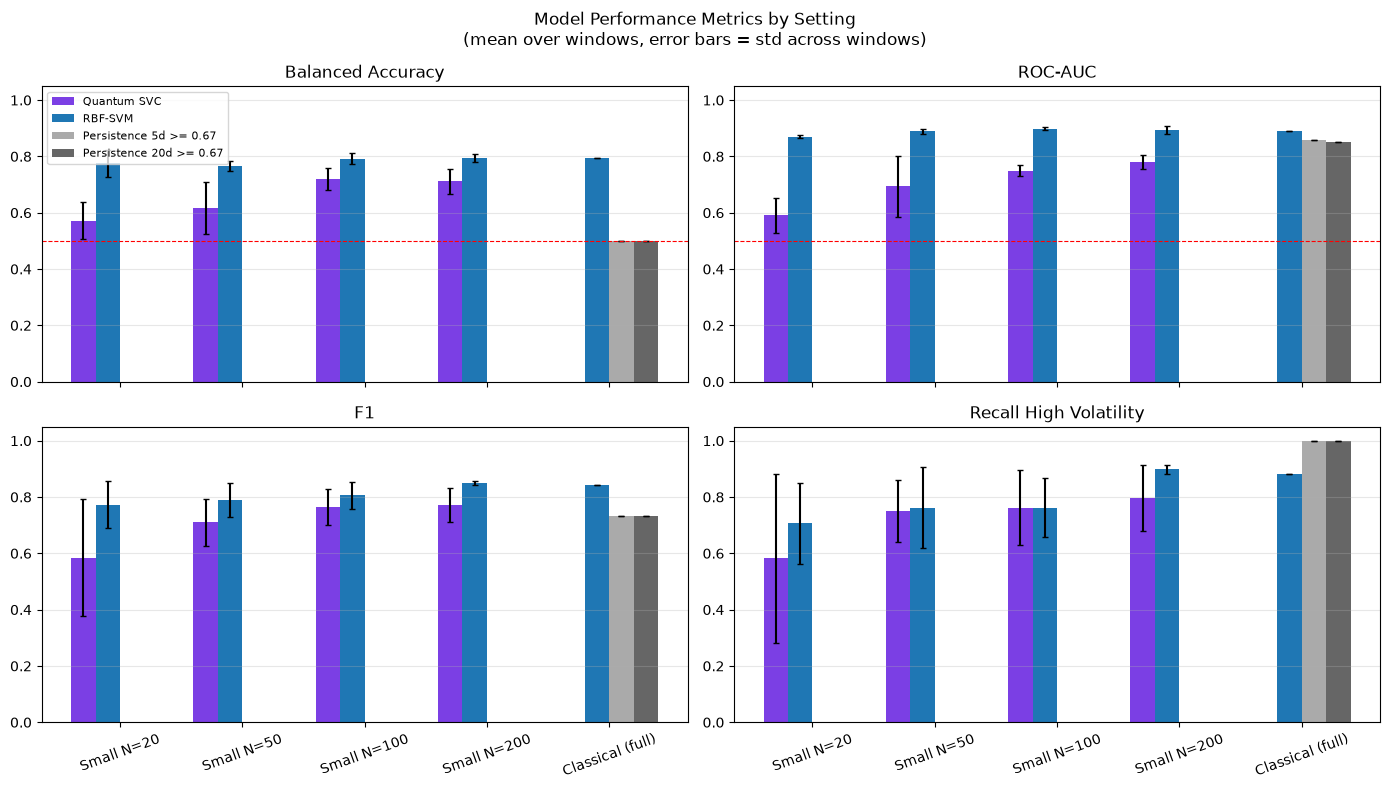

In [ ]:
visualize_global_summary()

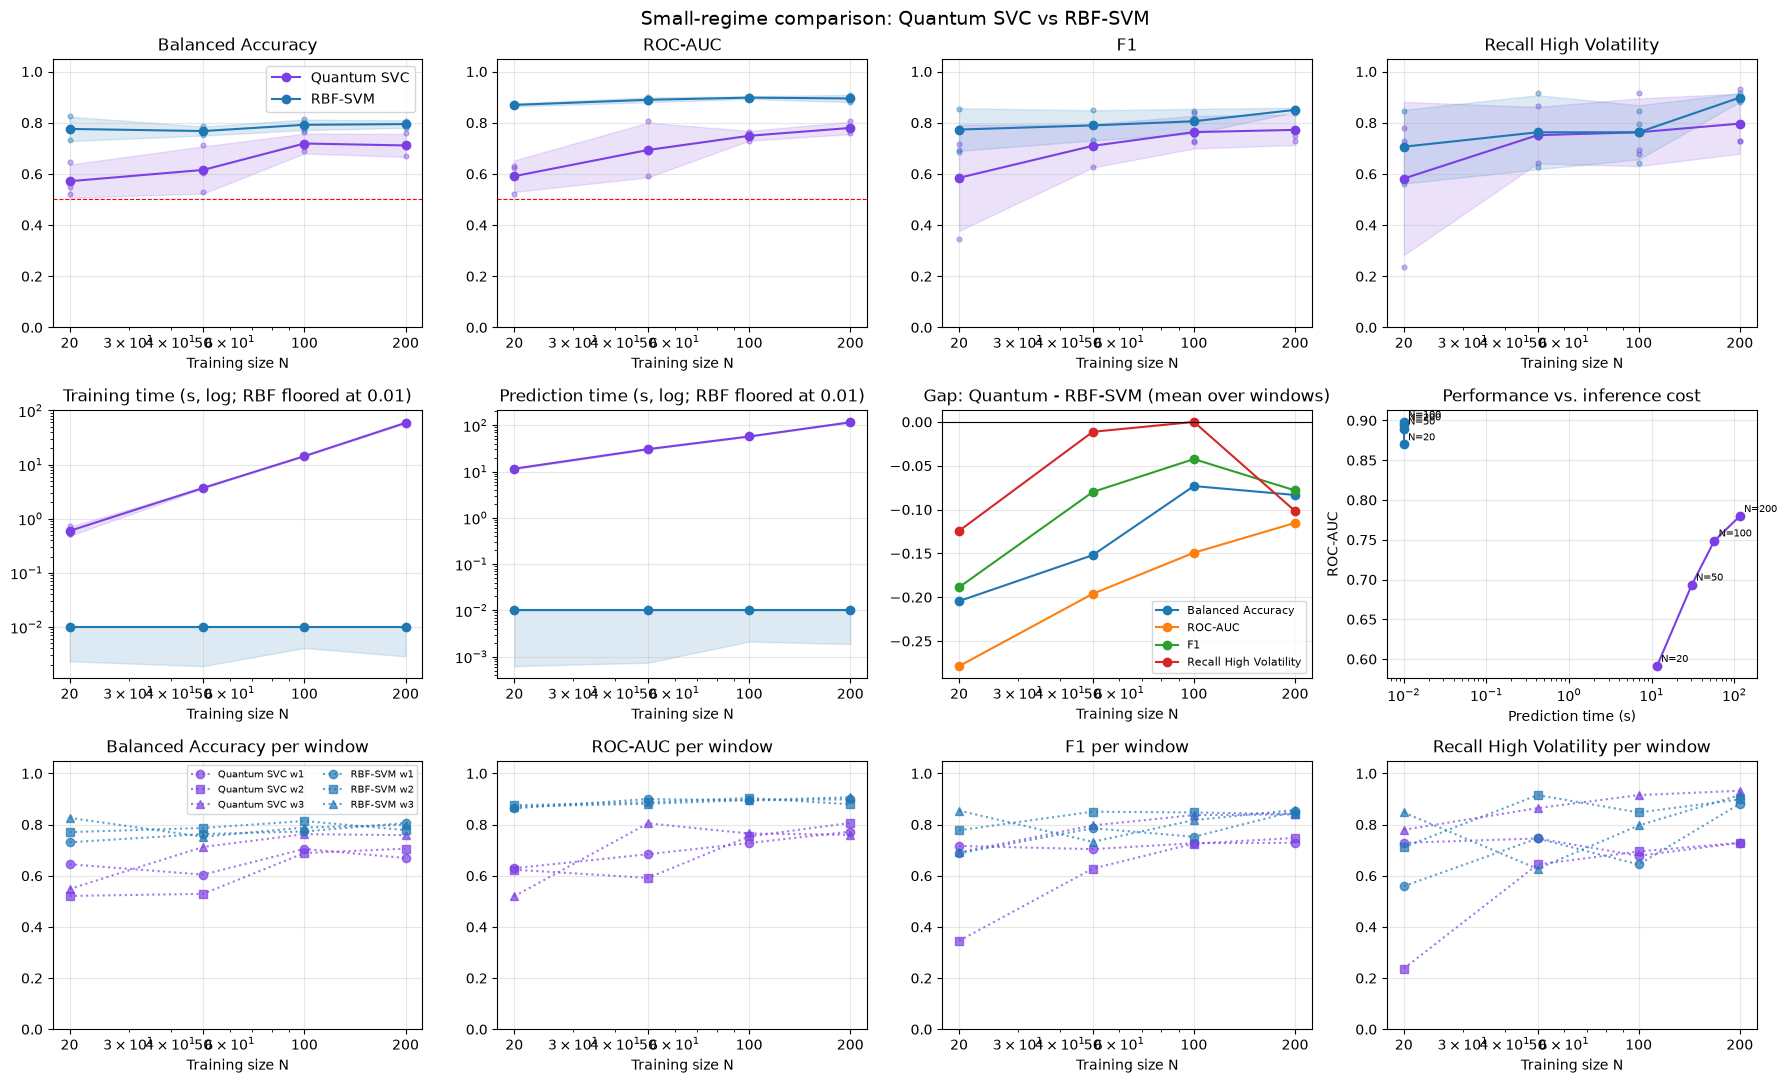

In [ ]:
visualize_small_regime()

# Extension: Bloomberg macro features

In [19]:
# --- 2Y / 10Y yields and spread ---

rates_2_10 = pd.read_csv(
    RAW_DIR / "spread 2-10.csv"
)

rates_2_10["Date"] = pd.to_datetime(
    rates_2_10["Date"]
)

rates_2_10 = rates_2_10.rename(columns={
    "USGG2YR Index": "yield_2y",
    "USGG10YR Index": "yield_10y",
    "USGG2YR Index - USGG10YR Index": "spread_2y_10y_bps"
})

rates_2_10 = (
    rates_2_10
    .set_index("Date")
    .sort_index()
)

print("2Y/10Y:")
print(rates_2_10.head())
print("Shape:", rates_2_10.shape)

2Y/10Y:
            yield_2y  yield_10y  spread_2y_10y_bps
Date                                              
2010-01-04    1.0638     3.8155          -275.1651
2010-01-05    1.0080     3.7608          -275.2852
2010-01-06    0.9920     3.8215          -282.9472
2010-01-07    1.0240     3.8235          -279.9551
2010-01-08    0.9759     3.8297          -285.3837
Shape: (3749, 3)


In [20]:
# --- VIX ---

vix = pd.read_csv(
    RAW_DIR / "VIX.csv",
    skiprows=1
)

vix.columns = ["Date", "vix"]

vix["Date"] = pd.to_datetime(
    vix["Date"],
    errors="coerce"
)

vix["vix"] = pd.to_numeric(
    vix["vix"],
    errors="coerce"
)

vix = (
    vix
    .dropna(subset=["Date"])
    .set_index("Date")
    .sort_index()
)

print("VIX:")
print(vix.head())
print("Shape:", vix.shape)
print("Range:", vix.index.min(), "to", vix.index.max())
print("Missing:", vix.isna().sum())

VIX:
              vix
Date             
2010-01-04  20.04
2010-01-05  19.35
2010-01-06  19.16
2010-01-07  19.06
2010-01-08  18.13
Shape: (3793, 1)
Range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00
Missing: vix    0
dtype: int64


In [21]:
# --- 3-month Treasury yield ---

rate_3m = pd.read_csv(
    RAW_DIR / "3M-2024-2010.csv",
    skiprows=5
)

rate_3m = rate_3m.rename(columns={
    "PX_LAST": "yield_3m"
})

rate_3m["Date"] = pd.to_datetime(
    rate_3m["Date"],
    errors="coerce"
)

rate_3m["yield_3m"] = pd.to_numeric(
    rate_3m["yield_3m"],
    errors="coerce"
)

rate_3m = (
    rate_3m[
        ["Date", "yield_3m"]
    ]
    .dropna(subset=["Date"])
    .set_index("Date")
    .sort_index()
)

print("3M Treasury:")
print(rate_3m.head())
print("Shape:", rate_3m.shape)
print("Range:", rate_3m.index.min(), "to", rate_3m.index.max())
print("Missing:", rate_3m.isna().sum())

3M Treasury:
            yield_3m
Date                
2009-12-31    0.0477
2010-01-01    0.0558
2010-01-04    0.0548
2010-01-05    0.0608
2010-01-06    0.0487
Shape: (3914, 1)
Range: 2009-12-31 00:00:00 to 2024-12-31 00:00:00
Missing: yield_3m    0
dtype: int64


In [22]:
print("SPX dates:", len(data.index))
print("VIX dates:", len(vix.index))
print("3M dates:", len(rate_3m.index))
print("2Y/10Y dates:", len(rates_2_10.index))

print("\nSPX dates missing in VIX:",
      len(data.index.difference(vix.index)))

print("SPX dates missing in 3M:",
      len(data.index.difference(rate_3m.index)))

print("SPX dates missing in 2Y/10Y:",
      len(data.index.difference(rates_2_10.index)))

SPX dates: 3774
VIX dates: 3793
3M dates: 3914
2Y/10Y dates: 3749

SPX dates missing in VIX: 0
SPX dates missing in 3M: 0
SPX dates missing in 2Y/10Y: 28


In [23]:
data_extended = (
    data
    .join(vix, how="left")
    .join(rate_3m, how="left")
    .join(
        rates_2_10[
            ["yield_2y", "yield_10y", "spread_2y_10y_bps"]
        ],
        how="left"
    )
)

print("Extended shape:", data_extended.shape)

print("\nMissing values before fill:")
print(
    data_extended[
        [
            "vix",
            "yield_3m",
            "yield_2y",
            "yield_10y",
            "spread_2y_10y_bps"
        ]
    ].isna().sum()
)

Extended shape: (3774, 18)

Missing values before fill:
vix                   0
yield_3m              0
yield_2y             28
yield_10y            28
spread_2y_10y_bps    28
dtype: int64


In [24]:
rate_cols = [
    "yield_2y",
    "yield_10y",
    "spread_2y_10y_bps"
]

data_extended[rate_cols] = (
    data_extended[rate_cols]
    .ffill()
)

print("\nMissing values after forward-fill:")
print(
    data_extended[
        [
            "vix",
            "yield_3m",
            "yield_2y",
            "yield_10y",
            "spread_2y_10y_bps"
        ]
    ].isna().sum()
)


Missing values after forward-fill:
vix                  0
yield_3m             0
yield_2y             0
yield_10y            0
spread_2y_10y_bps    0
dtype: int64


In [25]:
core_feature_cols = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d",
    "vix"
]

extended_feature_cols = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d",
    "vix",
    "yield_3m",
    "spread_2y_10y_bps"
]

In [26]:
model_data_extended = data_extended[
    extended_feature_cols
    + ["future_gk_vol_5d", "high_vol"]
].dropna().copy()

train_ext = model_data_extended.loc[
    "2010-01-01":"2020-12-31"
].iloc[:-H].copy()

val_ext = model_data_extended.loc[
    "2021-01-01":"2022-12-31"
].iloc[:-H].copy()

test_ext = model_data_extended.loc[
    "2023-01-01":"2024-12-31"
].copy()

print("Train:", train_ext.shape)
print("Validation:", val_ext.shape)
print("Test:", test_ext.shape)

Train: (2759, 9)
Validation: (498, 9)
Test: (497, 9)


In [ ]:
# OLD EVALUATE FEATURE SET, REMOVE THIS IF NEW ONE WORKS!
def evaluate_feature_set(feature_set, name):

    X_train = train_ext[feature_set]
    y_train = train_ext["high_vol"].astype(int)

    X_val = val_ext[feature_set]
    y_val = val_ext["high_vol"].astype(int)

    scaler = MinMaxScaler(
        feature_range=(0, np.pi),
        clip=True
    )

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_val_scaled)
    y_score = model.decision_function(X_val_scaled)

    return {
        "model": name,
        "balanced_accuracy": balanced_accuracy_score(
            y_val, y_pred
        ),
        "roc_auc": roc_auc_score(
            y_val, y_score
        ),
        "f1": f1_score(
            y_val, y_pred
        ),
        "recall": recall_score(
            y_val, y_pred
        )
    }

feature_comparison = pd.DataFrame([
    evaluate_feature_set(
        core_feature_cols,
        "Core 5 features"
    ),
    evaluate_feature_set(
        extended_feature_cols,
        "Extended 7 features"
    )
])

feature_comparison

,model,balanced_accuracy,roc_auc,f1,recall
0,Core 5 features,0.773313,0.887004,0.846986,0.951389
1,Extended 7 features,0.760466,0.853687,0.825040,0.892361


In [28]:
base_4_features = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d"
]

core_5_features = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d",
    "vix"
]

feature_comparison_4_vs_5 = pd.DataFrame([
    evaluate_feature_set(
        base_4_features,
        "Base 4 features"
    ),
    evaluate_feature_set(
        core_5_features,
        "Core 5 features + VIX"
    )
])

feature_comparison_4_vs_5

,model,balanced_accuracy,roc_auc,f1,recall
0,Base 4 features,0.795734,0.890823,0.842454,0.881944
1,Core 5 features + VIX,0.773313,0.887004,0.846986,0.951389


# NOUNOU COULDN'T RUN THIS!!!!

I don't have the datasets :(

If you run it you should have the full experiment.. hopefully

In [1669]:
def evaluate_feature_set(train, val, feature_set, name):
    X_train, y_train, X_val, y_val = prep_data(train, val, feature_set)
    X_train = train_ext[feature_set]
    y_train = train_ext["high_vol"].astype(int)

    X_val = val_ext[feature_set]
    y_val = val_ext["high_vol"].astype(int)

    X_train_scaled, X_val_scaled, start_date, end_date = scale_X(X_train, X_val)

    # baseline persistence
    persistence_baseline_with_threshold(X_val, y_val, threshold=THRESHOLD)

    # Full dataset
    rbf_results = rbf_svc_baseline(
        X_train_scaled=X_train_scaled,
        X_val_scaled=X_val_scaled,
        X_val=X_val,
        y_val=y_val,
        y_train=y_train,
        start_date=start_date,
        end_date=end_date,
        model_name=f"RBF-SVM ({name})",
        regime="Classical"
    )

    # Small dataset with windows

    train_thin, val_thin = thin_data(train, val, H)
    window_indices = generate_windows(train_thin, N_values=N_VALUES, n_windows=N_WINDOWS)
    datasets = prep_small_data(train_thin, window_indices,feature_set, N_values=N_VALUES)

    small_rbf_results = small_rbf_svm(datasets, model_name=f"RBF-SVM ({name})")
    small_rbf_aggregated_results = aggregate_window_metrics(small_rbf_results)

    quantum_results = small_q_svc(datasets, model_name=f"Quantum SVC ({name})")
    quantum_aggregated_results = aggregate_window_metrics(quantum_results)
      

# ATTENTION!!

L'output de cette partie est faux 
Vu que j'ai pas le dataset vix j'ai remplacé la colonne correspondant par une autre colonne du dataset afin de tester la pipeline finale.
J'ai clean up le code apres donc vous devriez pouvoir run de votre coté sans problème, **vous n'avez rien d'autre à corriger**.

,Split,N,Features,Positive labels,Positive rate
0,Train,2759,4,912,0.330555
1,Validation,498,4,288,0.578313


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 0.67,498,N/A,2021-01-04,2022-12-22,0.0,0.0,0.5,0.859127,0.732824,1.0


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 20d >= 0.67,498,N/A,2021-01-04,2022-12-22,0.0,0.0,0.5,0.852034,0.732824,1.0


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,RBF-SVM (Base 4 features),2759,N/A,2010-01-11,2020-12-23,0.101263,0.068564,0.795734,0.890823,0.842454,0.881944


   Dataset  Original size  Thinned size  Thinned high-volatility rate
     Train           2759           552                      0.327899
Validation            498           100                      0.590000


...

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM (Base 4 features),200,1,2010-01-11,2013-12-23,0.003151,0.002973,0.806532,0.898718,0.852459,0.881356


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM (Base 4 features),200,2,2013-07-11,2017-06-22,0.003718,0.002012,0.778421,0.879289,0.84127,0.898305


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM (Base 4 features),200,3,2017-01-06,2020-12-18,0.003193,0.001464,0.799091,0.906573,0.857143,0.915254


,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,RBF-SVM (Base 4 features),20,0.002255,0.000576,0.775872,0.047865,0.869781,0.006005,0.773326,0.083689,0.706215,0.144151
1,Validation,Small,RBF-SVM (Base 4 features),50,0.002294,0.000782,0.767535,0.017576,0.889624,0.009472,0.789594,0.058956,0.762712,0.144814
2,Validation,Small,RBF-SVM (Base 4 features),100,0.002650,0.001073,0.791925,0.020569,0.898167,0.005169,0.805775,0.048545,0.762712,0.105847
3,Validation,Small,RBF-SVM (Base 4 features),200,0.003354,0.002149,0.794681,0.014565,0.894860,0.014045,0.850291,0.008156,0.898305,0.016949


Generating Feature Map Circuit | N = 20 | Start : 2010-01-11 00:00:00 | End: 2010-05-27 00:00:00
Number of qubits: 4
Circuit depth: 11


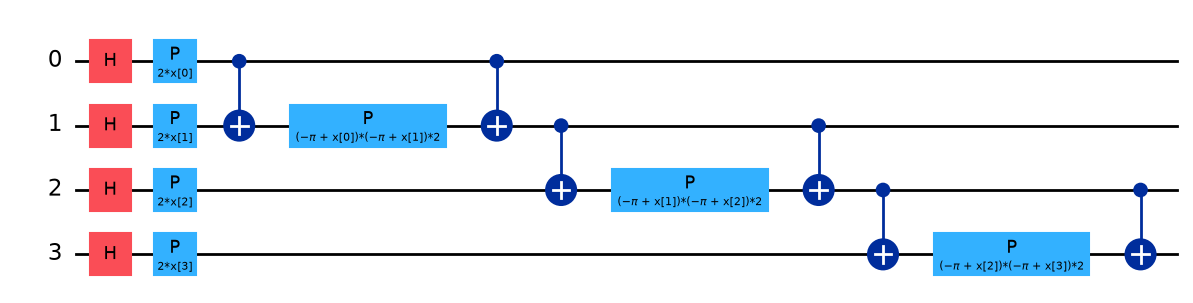

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),20,1,2010-01-11,2010-05-27,0.52695,11.797227,0.644895,0.629599,0.716667,0.728814


Generating Feature Map Circuit | N = 20 | Start : 2015-04-24 00:00:00 | End: 2015-09-09 00:00:00
Number of qubits: 4
Circuit depth: 11


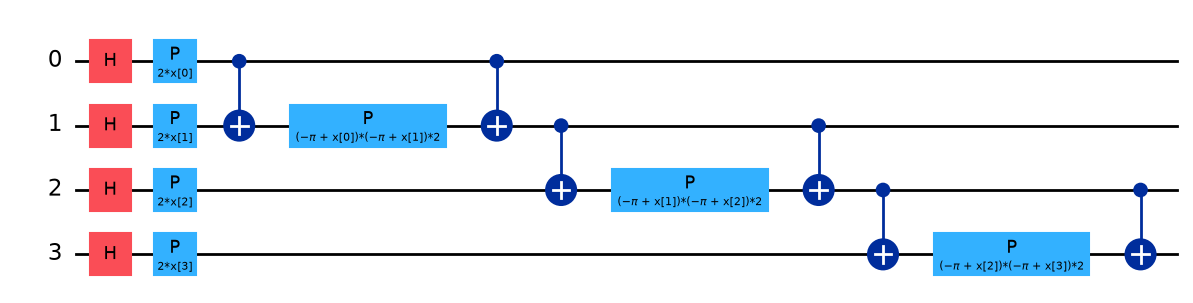

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),20,2,2015-04-24,2015-09-09,0.551795,11.715437,0.521083,0.623811,0.345679,0.237288


Generating Feature Map Circuit | N = 20 | Start : 2020-08-05 00:00:00 | End: 2020-12-18 00:00:00
Number of qubits: 4
Circuit depth: 11


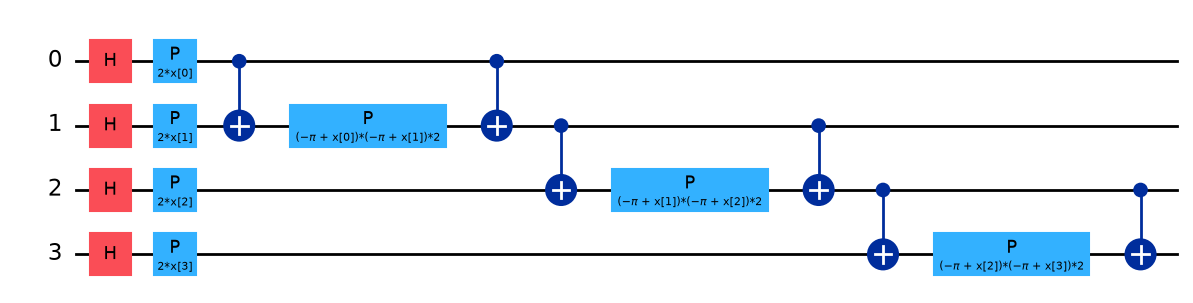

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),20,3,2020-08-05,2020-12-18,0.545683,11.914769,0.548367,0.52005,0.691729,0.779661


Generating Feature Map Circuit | N = 50 | Start : 2010-01-11 00:00:00 | End: 2010-12-30 00:00:00
Number of qubits: 4
Circuit depth: 11


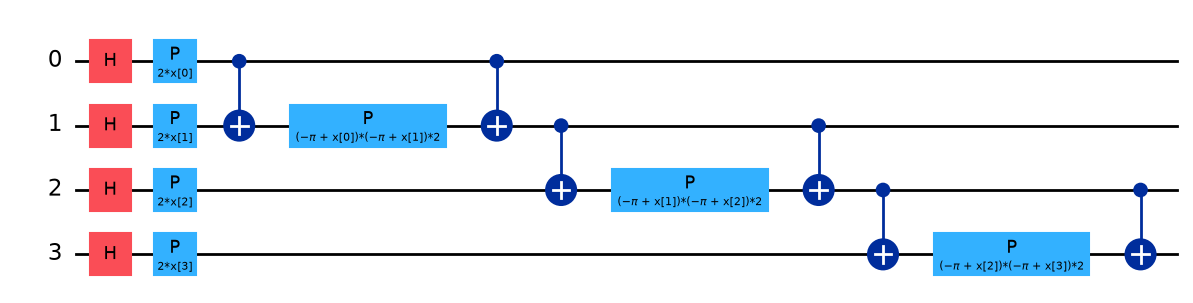

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),50,1,2010-01-11,2010-12-30,3.852771,29.138247,0.604589,0.684167,0.704,0.745763


Generating Feature Map Circuit | N = 50 | Start : 2015-01-06 00:00:00 | End: 2015-12-24 00:00:00
Number of qubits: 4
Circuit depth: 11


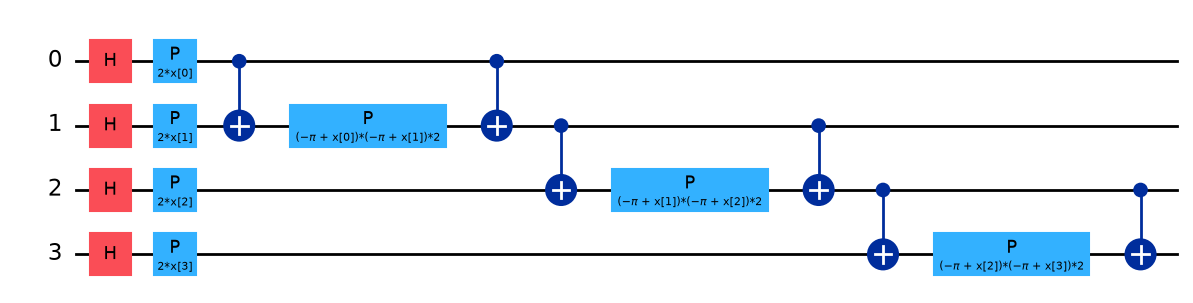

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),50,2,2015-01-06,2015-12-24,3.461787,28.599011,0.529351,0.591567,0.628099,0.644068


Generating Feature Map Circuit | N = 50 | Start : 2019-12-31 00:00:00 | End: 2020-12-18 00:00:00
Number of qubits: 4
Circuit depth: 11


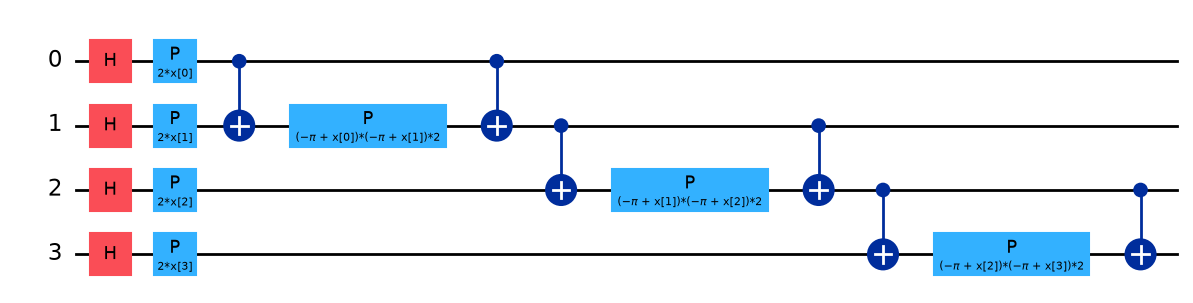

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),50,3,2019-12-31,2020-12-18,3.625017,28.305262,0.712691,0.804878,0.796875,0.864407


Generating Feature Map Circuit | N = 100 | Start : 2010-01-11 00:00:00 | End: 2011-12-27 00:00:00
Number of qubits: 4
Circuit depth: 11


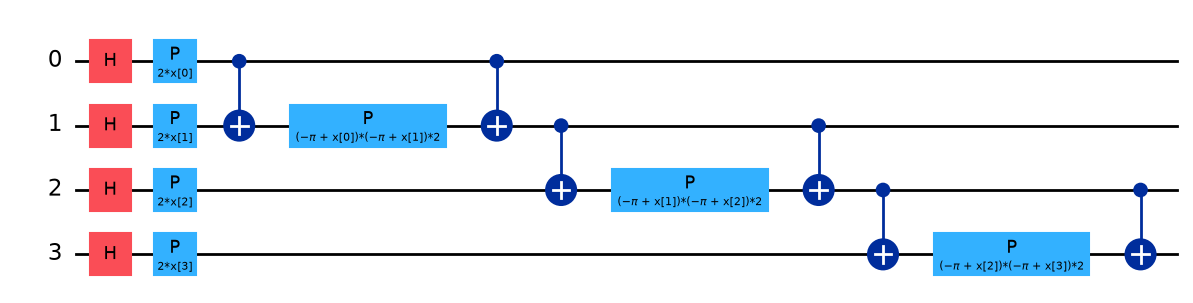

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),100,1,2010-01-11,2011-12-27,14.235163,56.254206,0.704837,0.727987,0.727273,0.677966


Generating Feature Map Circuit | N = 100 | Start : 2014-07-09 00:00:00 | End: 2016-06-24 00:00:00
Number of qubits: 4
Circuit depth: 11


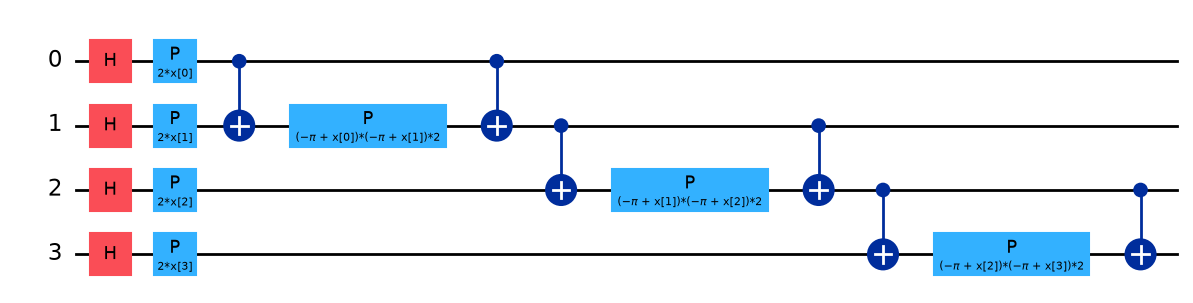

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),100,2,2014-07-09,2016-06-24,14.383141,59.011923,0.688921,0.753617,0.725664,0.694915


Generating Feature Map Circuit | N = 100 | Start : 2019-01-03 00:00:00 | End: 2020-12-18 00:00:00
Number of qubits: 4
Circuit depth: 11


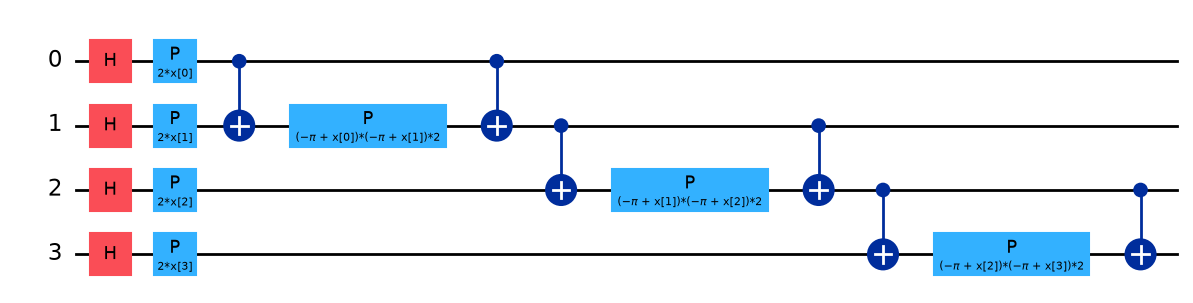

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),100,3,2019-01-03,2020-12-18,14.268043,63.165704,0.762505,0.765192,0.837209,0.915254


Generating Feature Map Circuit | N = 200 | Start : 2010-01-11 00:00:00 | End: 2013-12-23 00:00:00
Number of qubits: 4
Circuit depth: 11


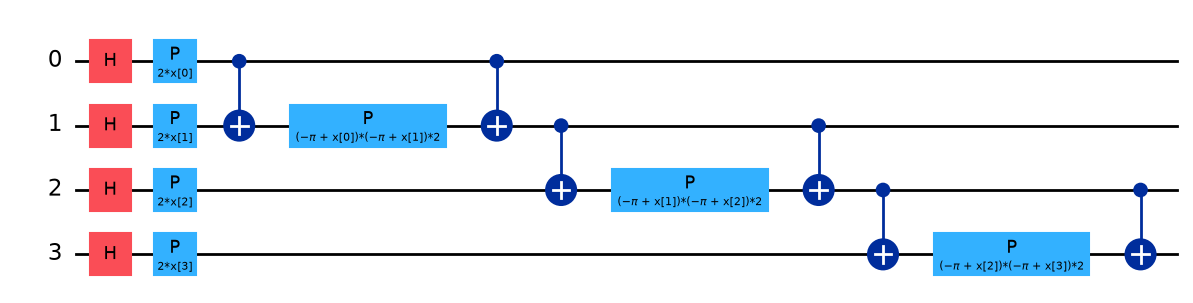

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),200,1,2010-01-11,2013-12-23,74.534441,141.568061,0.669285,0.772633,0.728814,0.728814


Generating Feature Map Circuit | N = 200 | Start : 2013-07-11 00:00:00 | End: 2017-06-22 00:00:00
Number of qubits: 4
Circuit depth: 11


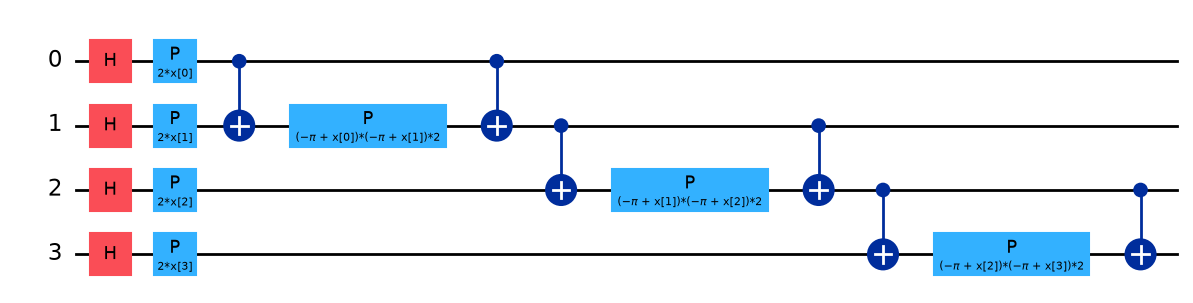

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),200,2,2013-07-11,2017-06-22,68.521627,127.539265,0.70587,0.806532,0.747826,0.728814


Generating Feature Map Circuit | N = 200 | Start : 2017-01-06 00:00:00 | End: 2020-12-18 00:00:00
Number of qubits: 4
Circuit depth: 11


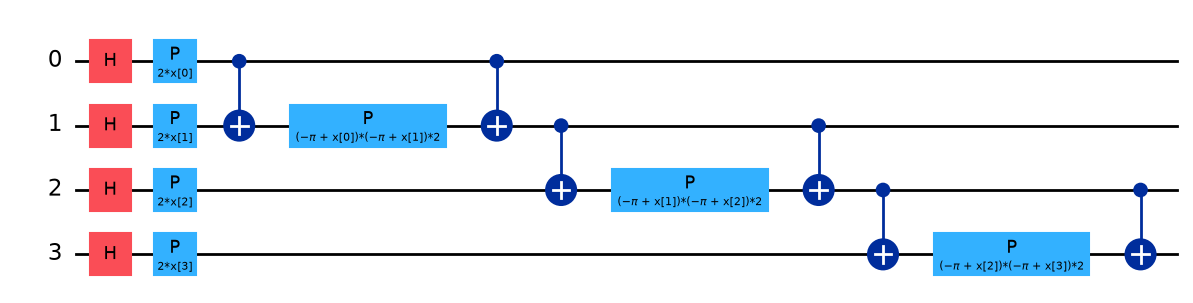

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,Quantum SVC (Base 4 features),200,3,2017-01-06,2020-12-18,59.848208,131.565776,0.758785,0.759818,0.839695,0.932203


,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,Quantum SVC (Base 4 features),20,0.541476,11.809144,0.571448,0.065053,0.591153,0.061646,0.584692,0.207366,0.581921,0.299542
1,Validation,Small,Quantum SVC (Base 4 features),50,3.646525,28.680840,0.615544,0.092160,0.693537,0.106964,0.709658,0.084530,0.751412,0.110278
2,Validation,Small,Quantum SVC (Base 4 features),100,14.295449,59.477278,0.718754,0.038716,0.748932,0.019040,0.763382,0.063941,0.762712,0.132377
3,Validation,Small,Quantum SVC (Base 4 features),200,67.634759,133.557701,0.711313,0.044997,0.779661,0.024137,0.772111,0.059296,0.796610,0.117427


,Split,N,Features,Positive labels,Positive rate
0,Train,2759,5,912,0.330555
1,Validation,498,5,288,0.578313


DuplicateError: Expected unique column names, got:
- 'gk_vol_20d' 2 times

In [1672]:
reset_results()

base_4_features = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d"
]

core_5_features = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d",
    "vix"
]

evaluate_feature_set(train_ext, val_ext, base_4_features, "Base 4 features")
evaluate_feature_set(train_ext, val_ext, core_5_features, "Core 5 features + VIX")

In [1673]:
global_summary_table()

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.859127,0.732824,1.000000
1,Classical,Validation,Persistence 20d >= 0.67,498,N/A,2021-01-04,2022-12-22,0 min 0.00 sec,0 min 0.00 sec,0.500000,0.852034,0.732824,1.000000
2,Classical,Validation,RBF-SVM (Base 4 features),2759,N/A,2010-01-11,2020-12-23,0 min 0.10 sec,0 min 0.07 sec,0.795734,0.890823,0.842454,0.881944
3,Small,Validation,RBF-SVM (Base 4 features),20,1,2010-01-11,2010-05-27,0 min 0.00 sec,0 min 0.00 sec,0.730881,0.863580,0.687500,0.559322
4,Small,Validation,RBF-SVM (Base 4 features),20,2,2015-04-24,2015-09-09,0 min 0.00 sec,0 min 0.00 sec,0.770566,0.875568,0.777778,0.711864
5,Small,Validation,RBF-SVM (Base 4 features),20,3,2020-08-05,2020-12-18,0 min 0.00 sec,0 min 0.00 sec,0.826168,0.870194,0.854701,0.847458
6,Small,Validation,RBF-SVM (Base 4 features),50,1,2010-01-11,2010-12-30,0 min 0.00 sec,0 min 0.00 sec,0.763125,0.899959,0.785714,0.745763
7,Small,Validation,RBF-SVM (Base 4 features),50,2,2015-01-06,2015-12-24,0 min 0.00 sec,0 min 0.00 sec,0.786895,0.887557,0.850394,0.915254
8,Small,Validation,RBF-SVM (Base 4 features),50,3,2019-12-31,2020-12-18,0 min 0.00 sec,0 min 0.00 sec,0.752584,0.881356,0.732673,0.627119
9,Small,Validation,RBF-SVM (Base 4 features),100,1,2010-01-11,2011-12-27,0 min 0.00 sec,0 min 0.00 sec,0.773253,0.894585,0.752475,0.644068


In [1674]:
macro_summary_table()

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,RBF-SVM (Base 4 features),20,0 min 0.00 sec,0 min 0.00 sec,0.775872,0.047865,0.869781,0.006005,0.773326,0.083689,0.706215,0.144151
1,Validation,Small,RBF-SVM (Base 4 features),50,0 min 0.00 sec,0 min 0.00 sec,0.767535,0.017576,0.889624,0.009472,0.789594,0.058956,0.762712,0.144814
2,Validation,Small,RBF-SVM (Base 4 features),100,0 min 0.00 sec,0 min 0.00 sec,0.791925,0.020569,0.898167,0.005169,0.805775,0.048545,0.762712,0.105847
3,Validation,Small,RBF-SVM (Base 4 features),200,0 min 0.00 sec,0 min 0.00 sec,0.794681,0.014565,0.894860,0.014045,0.850291,0.008156,0.898305,0.016949
4,Validation,Small,Quantum SVC (Base 4 features),20,0 min 0.54 sec,0 min 11.81 sec,0.571448,0.065053,0.591153,0.061646,0.584692,0.207366,0.581921,0.299542
5,Validation,Small,Quantum SVC (Base 4 features),50,0 min 3.65 sec,0 min 28.68 sec,0.615544,0.092160,0.693537,0.106964,0.709658,0.084530,0.751412,0.110278
6,Validation,Small,Quantum SVC (Base 4 features),100,0 min 14.30 sec,0 min 59.48 sec,0.718754,0.038716,0.748932,0.019040,0.763382,0.063941,0.762712,0.132377
7,Validation,Small,Quantum SVC (Base 4 features),200,1 min 7.63 sec,2 min 13.56 sec,0.711313,0.044997,0.779661,0.024137,0.772111,0.059296,0.796610,0.117427


In [1675]:
save_results_to_csv(suffix="feature_comparison")

Results saved to CSV files.


# ATTENTION

### CES DEUX FONCTIONS NE FONCTIONNERONT PROBABLEMENT PAS AVEC LES RESULTATS A CAUSE DES NOMS DE MODELES
 Il faut donc les adapter  aux nouveaux noms de modeles. 


In [ ]:

def visualize_global_summary_2(d=None, small_regime="Small", colors=None):
    """Bar charts of mean metrics per setting and model.
 
    Models, settings and colors are all inferred from the data, so renaming,
    adding or removing models/regimes/Ns needs no code changes.
    """
    metrics = ["Balanced Accuracy", "ROC-AUC", "F1", "Recall High Volatility"]
 
    d = global_summary_table() if d is None else d.copy()
 
    # Small regime is split by N; every other regime is its own group
    d["Setting"] = np.where(d["Data Regime"] == small_regime,
                            "Small N=" + d["N"].astype(str),
                            d["Data Regime"].astype(str))
 
    # Macro-average over windows (mean + std across windows; std=0 if single run)
    g = d.groupby(["Setting", "Model"])[metrics]
    mean, std = g.mean(), g.std().fillna(0)
 
    # Settings: small-regime Ns in numeric order, then other regimes as they appear
    small_ns = sorted(d.loc[d["Data Regime"] == small_regime, "N"].unique())
    order = [f"Small N={n}" for n in small_ns]
    order += [r for r in d["Data Regime"].astype(str).unique() if r != small_regime]
 
    # Models: those present in the small regime first (the focus), then the rest,
    # each in order of appearance
    small_models = list(d.loc[d["Data Regime"] == small_regime, "Model"].unique())
    models = small_models + [m for m in d["Model"].unique() if m not in small_models]
 
    # Purple / blue / greys scheme, assigned by position (no model names needed)
    palette = [ "#1f77b4", "#7b3fe4", "#aaaaaa", "#666666",
                "#6fb1e0", "#b48ef0", "#cccccc", "#333333"]
    auto = {m: palette[i % len(palette)] for i, m in enumerate(models)}
    colors = {**auto, **(colors or {})}  # optional per-model overrides
 
    n_models = len(models)
    w = 0.8 / n_models
 
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, m in zip(axes.ravel(), metrics):
        for i, mod in enumerate(models):
            xs, ys, es = [], [], []
            for j, s in enumerate(order):
                if (s, mod) in mean.index:
                    xs.append(j + (i - (n_models - 1) / 2) * w)
                    ys.append(mean.loc[(s, mod), m])
                    es.append(std.loc[(s, mod), m])
            ax.bar(xs, ys, w, yerr=es, capsize=2, label=mod, color=colors[mod])
        if m in ("Balanced Accuracy", "ROC-AUC"):
            ax.axhline(0.5, ls="--", c="red", lw=0.8)  # chance level
        ax.set_title(m)
        ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=20)
        ax.grid(axis="y", alpha=0.3)
 
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Model Performance Metrics by Setting\n"
                 "(mean over windows, error bars = std across windows)")
    plt.tight_layout()
    plt.show()
    return mean, std
 

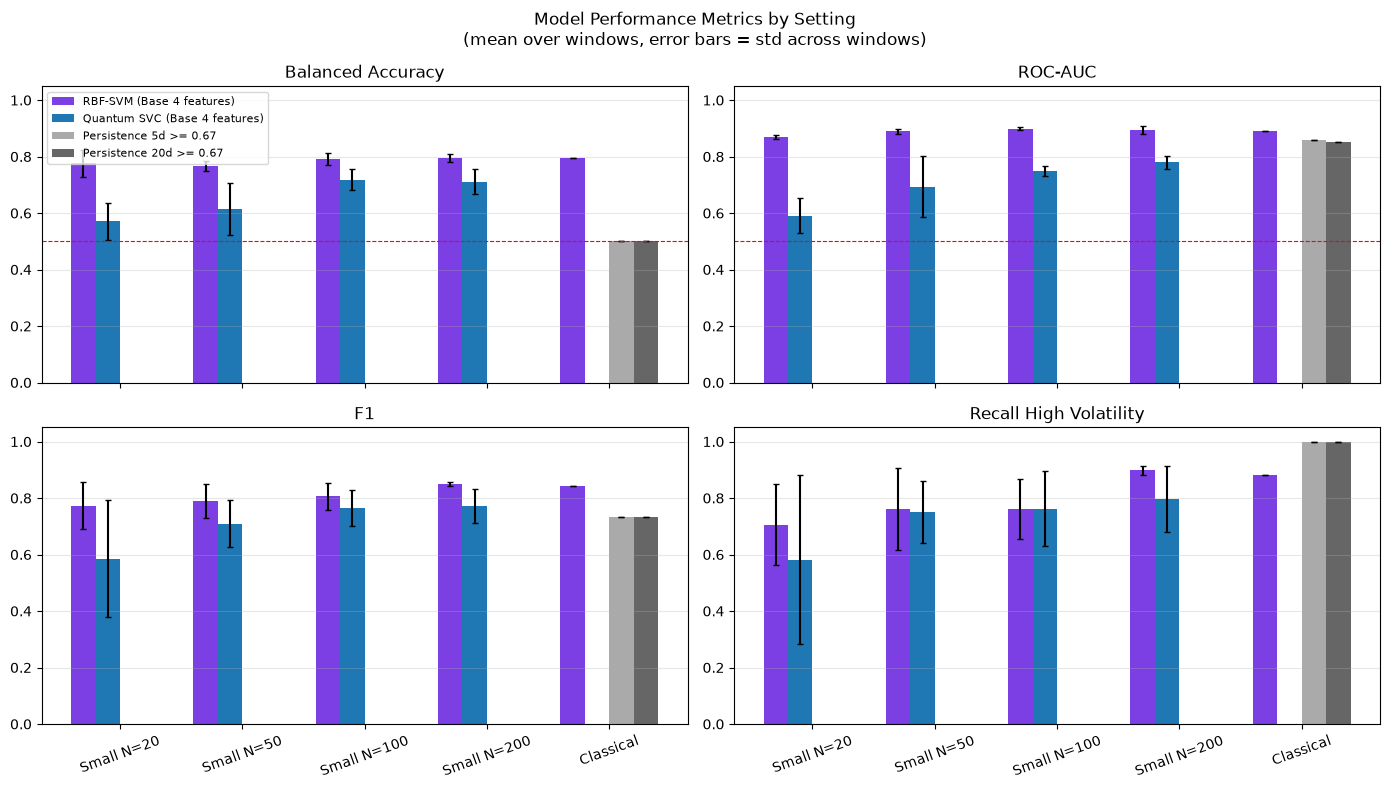

(                                           Balanced Accuracy   ROC-AUC  \
 Setting     Model                                                        
 Classical   Persistence 20d >= 0.67                 0.500000  0.852034   
             Persistence 5d >= 0.67                  0.500000  0.859127   
             RBF-SVM (Base 4 features)               0.795734  0.890823   
 Small N=100 Quantum SVC (Base 4 features)           0.718754  0.748932   
             RBF-SVM (Base 4 features)               0.791925  0.898167   
 Small N=20  Quantum SVC (Base 4 features)           0.571448  0.591153   
             RBF-SVM (Base 4 features)               0.775872  0.869781   
 Small N=200 Quantum SVC (Base 4 features)           0.711313  0.779661   
             RBF-SVM (Base 4 features)               0.794681  0.894860   
 Small N=50  Quantum SVC (Base 4 features)           0.615544  0.693537   
             RBF-SVM (Base 4 features)               0.767535  0.889624   
 
                       

In [1681]:
visualize_global_summary_2()

KeyError: 'Quantum SVC'

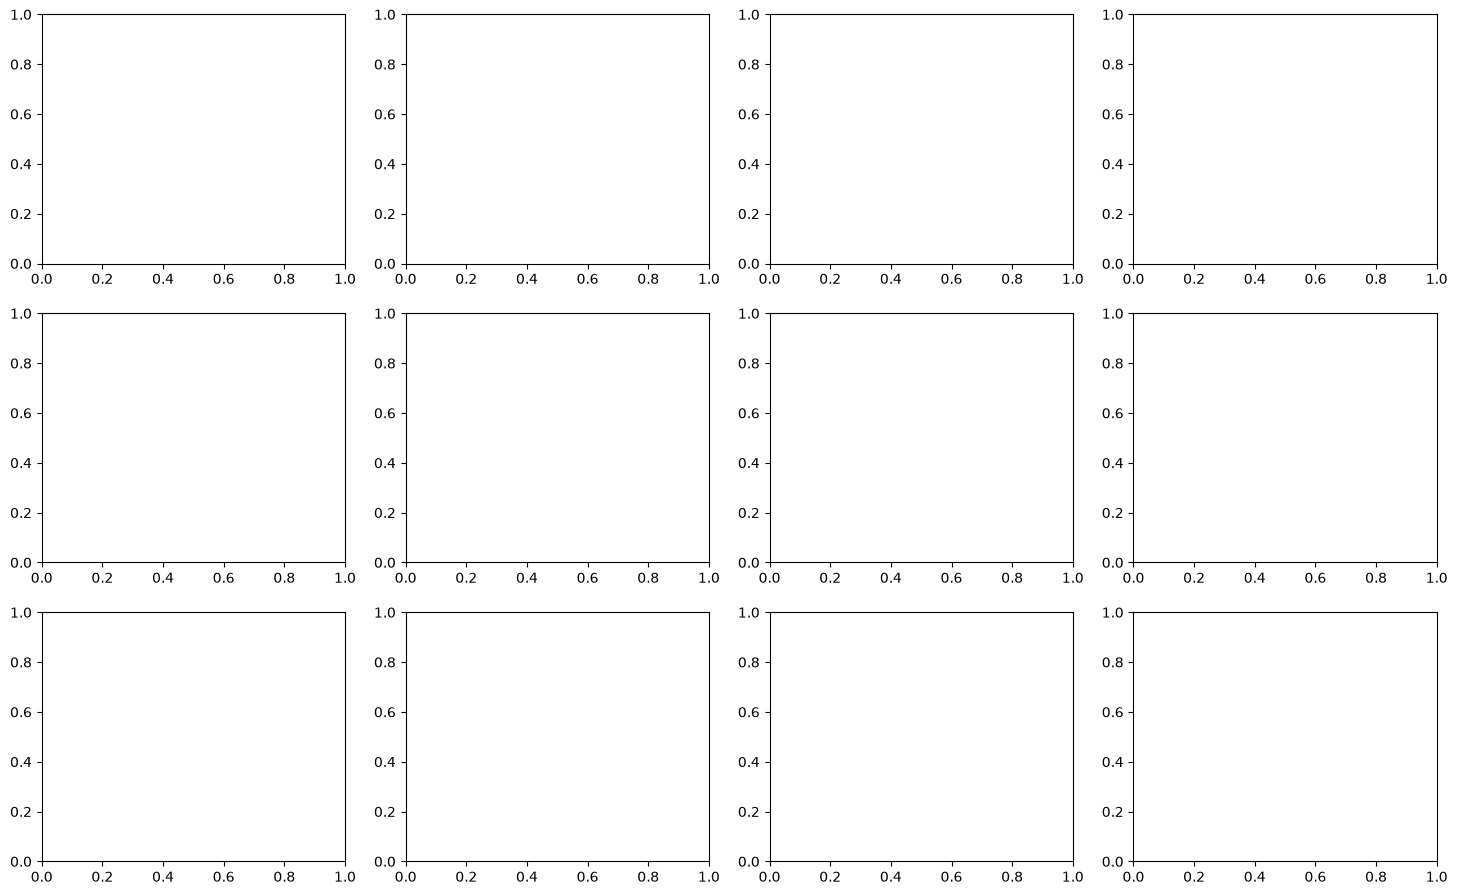

In [1677]:
visualize_small_regime()